# Aprendizaje por Refuerzo - Proyecto Final con ambiente de dos Habitaciones
## Solución con Q-learning off-policy



* **Ing. Daniel Arturo Martínez Morales** - Estudiante de maestría MIAD  
* **Ing. Luis Miguel Ortega Cañate** - Estudiante de maestría MIAD  



### Descripción general

Este notebook implementa, entrena y evalúa un agente de Q-learning para resolver el problema de navegación en un ambiente de dos habitaciones separadas por una puerta con llave, tal como se propuso en la definición y descripción del proyecto final del curso en la semana 1 de Coursera.

El agente debe completar una secuencia de subtareas:

1. Recoger la bola que bloquea la puerta  
2. Recoger la llave azul  
3. Abrir la puerta usando la llave  
4. Navegar hasta la casilla de salida en la habitación derecha  



### Estructura del notebook

| Sección | Contenido |
|---|---|
| 1 | Imports y configuración |
| 2 | Definición del ambiente |
| 3 | Agente Q-learning |
| 4 | Persistencia de la Q-tabla |
| 5 | Entrenamiento |
| 6 | Curvas de aprendizaje |
| 7 | Evaluación y casos de prueba |
| 8 | Mapas de calor de la Q-tabla |
| 9 | Política óptima |
| 10 | Demostración animada |
| 11 | Resumen de resultados |
| 12 | Pruebas cargando qtabla desde .json |


## 1. Imports y Configuración

Se importan las librerías necesarias y se definen las constantes del ambiente.  
El ambiente es una grilla de **9 columnas × 4 filas** con coordenadas `(col, row)`, donde `(0, 0)` está en la esquina inferior izquierda.


In [1]:
# Se importan las librerías necesarias para el entorno, el agente, y la visualización
import random, json, csv, os, time
import matplotlib
matplotlib.use('Agg')
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
from IPython.display import Image, display
import numpy as np

# Dimensiones del ambiente y parámetros
NROWS     = 4          # filas  (y: 0 = inferior, 3 = superior)
NCOLS     = 9          # columnas totales
DOOR_COL  = 4          # columna de la pared divisoria
MAX_STEPS = 300        # pasos máximos por episodio (timeout)

# Posiciones fijas (col, row)
AGENT_START = (0, 0)   # posición inicial del agente
KEY_POS     = (3, 2)   # llave azul
BALL_POS    = (3, 0)   # bola roja (bloquea la puerta)
DOOR_POS    = (4, 0)   # la única celda de la pared que es puerta
EXIT_POS    = (6, 3)   # casilla de salida (desconocida para el agente)

# Acciones disponibles
ACTIONS = ['up', 'down', 'left', 'right', 'pick', 'drop', 'open_door']

print("Configuración cargada.")
print(f"Grilla: {NCOLS}×{NROWS}  |  Acciones: {len(ACTIONS)}  |  MAX_STEPS: {MAX_STEPS}")

Configuración cargada.
Grilla: 9×4  |  Acciones: 7  |  MAX_STEPS: 300


## 2. Definición del Ambiente: `TwoRoomEnv`

El ambiente se define conforme a lo ya indicado en el reporte de entrega parcial del proyecto de la semana 5 del curso.

### 2.1 Espacio de estados

El estado completo se representa como una tupla de 5 componentes: S = (pos_agente, tiene_objeto, tipo_obj, bola_retirada, puerta_abierta)


| Variable | Tipo | Valores | Descripción |
|---|---|---|---|
| `pos_agente` | Discreta | `(col, row)` en `{0-8} × {0-3}` | Coordenadas (col, fila) del agente en la grilla. 9 columnas × 4 filas: habitación izquierda (cols 0-3), puerta (col 4), habitación derecha (cols 5-8). |
| `tiene_objeto` | Booleano | `{False, True}` | Indica si el agente carga algún objeto en su inventario. |
| `tipo_obj` | Categórico | `{None, 'bola', 'llave'}` | Tipo de objeto que lleva el agente. None si tiene_objeto=False. |
| `bola_retirada` | Booleano | `{False, True}` | Indica si la bola roja ya fue retirada del bloqueo de la puerta (recogida o desplazada). |
| `puerta_abierta` | Booleano | `{False, True}` | Indica si la puerta entre habitaciones está abierta. |

### 2.2 Restricciones de movimiento

- Muros permanentes: celdas `(4,1)`, `(4,2)`, `(4,3)` definen el muro fijo que separa ambas habitaciones y el agente no puede atravesar.  
- Puerta condicional: celda `(4,0)` define la puerta que se puede atravesar solo si `door_open = True`.  
- El método `_is_wall(col, row)` se encarga de establecer la lógica de colisión la pared que separa las habitaciones.

### 2.3 Función de recompensa

| Evento | Recompensa |
|---|---|
| Recoger bola / llave (1ª vez) | +0.3 |
| Soltar bola | +0.1 |
| Abrir puerta | +0.5 |
| Cruzar la puerta | +0.2 |
| Alcanzar la salida | **+1.0** |
| Paso normal | −0.01 |
| Chocar con muro/borde | −0.02 |
| Intentar abrir sin precondiciones | −0.1 |
| Timeout | **−1.0** |


In [2]:
class TwoRoomEnv:
    def __init__(self):
        self.exit_pos = EXIT_POS
        self.reset()

    # Reset
    def reset(self):
        self.agent_pos    = AGENT_START
        self.has_object   = False
        self.object_type  = None
        self.ball_removed = False
        self.door_open    = False
        self.steps        = 0
        self.ball_map_pos = BALL_POS
        self.key_map_pos  = KEY_POS
        # Flags para evitar recompensas duplicadas en el mismo episodio
        self._rewarded_pick_ball  = False
        self._rewarded_pick_key   = False
        self._rewarded_open_door  = False
        self._rewarded_cross_door = False
        return self._get_state()

    def _get_state(self):
        return (self.agent_pos, self.has_object,
                self.object_type, self.ball_removed, self.door_open)

    # Lógica de muros
    def _is_wall(self, col, row):
        if col == DOOR_COL:
            if row != DOOR_POS[1]:
                return True
            return not self.door_open
        return False

    # Acciones posibles
    def get_possible_actions(self):
        col, row = self.agent_pos
        actions  = []
        if row < NROWS - 1 and not self._is_wall(col, row + 1): actions.append('up')
        if row > 0          and not self._is_wall(col, row - 1): actions.append('down')
        if col > 0          and not self._is_wall(col - 1, row): actions.append('left')
        if col < NCOLS - 1  and not self._is_wall(col + 1, row): actions.append('right')
        if not self.has_object:
            if self.ball_map_pos == self.agent_pos and not self.ball_removed:
                actions.append('pick')
            if self.key_map_pos == self.agent_pos:
                actions.append('pick')
        if self.has_object:
            actions.append('drop')
        actions.append('open_door')
        return actions

    # Step
    def step(self, action: str):
        self.steps += 1
        col, row = self.agent_pos
        reward, done, info = 0.0, False, ""

        if action in ('up', 'down', 'left', 'right'):
            nc, nr = col, row
            if   action == 'up':    nr += 1
            elif action == 'down':  nr -= 1
            elif action == 'left':  nc -= 1
            elif action == 'right': nc += 1

            if not (0 <= nc < NCOLS and 0 <= nr < NROWS):
                reward, info = -0.02, "pared_borde"
            elif self._is_wall(nc, nr):
                reward = -0.02
                info   = "puerta_cerrada" if (nc == DOOR_COL and nr == DOOR_POS[1]) else "muro"
            else:
                self.agent_pos = (nc, nr)
                if col == DOOR_COL and nc > DOOR_COL and not self._rewarded_cross_door:
                    reward += 0.2; self._rewarded_cross_door = True; info = "cruzo_puerta"
                if self.agent_pos == self.exit_pos:
                    reward += 1.0; done = True; info = "salida_alcanzada"
                elif info == "":
                    reward = -0.01

        elif action == 'pick':
            if self.has_object:
                reward, info = -0.05, "ya_carga_objeto"
            elif self.ball_map_pos == self.agent_pos and not self.ball_removed:
                if self._rewarded_pick_ball:
                    reward, info = -0.05, "bola_ya_recogida"
                else:
                    self.has_object, self.object_type, self.ball_removed = True, 'bola', True
                    reward = 0.3; self._rewarded_pick_ball = True; info = "recogió_bola"
            elif self.key_map_pos == self.agent_pos:
                if self._rewarded_pick_key:
                    reward, info = -0.05, "llave_ya_recogida"
                else:
                    self.has_object, self.object_type = True, 'llave'
                    reward = 0.3; self._rewarded_pick_key = True; info = "recogió_llave"
            else:
                reward, info = -0.01, "nada_que_recoger"

        elif action == 'drop':
            if not self.has_object:
                reward, info = -0.01, "no_carga_nada"
            else:
                if self.object_type == 'bola':
                    self.ball_map_pos = self.agent_pos; reward = 0.1; info = "soltó_bola"
                else:
                    self.key_map_pos = self.agent_pos; reward = -0.01; info = "soltó_llave"
                self.has_object, self.object_type = False, None

        elif action == 'open_door':
            adj = (col == DOOR_COL - 1 and row == DOOR_POS[1])
            can_open = adj and self.has_object and self.object_type == 'llave' \
                       and self.ball_removed and not self.door_open
            if can_open:
                self.door_open = True; reward = 0.5
                self._rewarded_open_door = True; info = "abrió_puerta"
            else:
                reward, info = -0.1, "no_puede_abrir"

        if self.steps >= MAX_STEPS and not done:
            reward += -1.0; done = True; info += "|timeout"

        return self._get_state(), reward, done, info

    def is_terminal(self, state=None):
        if state is None:
            return self.agent_pos == self.exit_pos or self.steps >= MAX_STEPS
        return state[0] == self.exit_pos

    # Render
    def render(self, ax=None, title=""):
        if ax is None:
            fig, ax = plt.subplots(figsize=(11, 5))
        else:
            fig = ax.get_figure()
        ax.clear()
        ax.set_xlim(0, NCOLS); ax.set_ylim(0, NROWS)
        ax.set_aspect('equal'); ax.set_facecolor('#1a1a2e')
        fig.patch.set_facecolor('#0f0f1a')

        ax.add_patch(plt.Rectangle((0,0), DOOR_COL, NROWS, color='#16213e', zorder=0))
        ax.add_patch(plt.Rectangle((DOOR_COL+1,0), NCOLS-DOOR_COL-1, NROWS, color='#16213e', zorder=0))
        ax.add_patch(plt.Rectangle((DOOR_COL, 1), 1, NROWS-1, color='#475569', zorder=1))
        for x in range(NCOLS+1): ax.axvline(x, color='#475569', lw=0.5, zorder=2)
        for y in range(NROWS+1): ax.axhline(y, color='#475569', lw=0.5, zorder=2)

        dc, dr = DOOR_POS
        ax.add_patch(plt.Rectangle((dc,dr),1,1,
            color='#2563eb' if self.door_open else '#1e3a5f', zorder=3))
        ax.text(dc+0.5, dr+0.5, 'OPEN' if self.door_open else 'LOCK',
                ha='center', va='center', color='white', fontsize=7, fontweight='bold', zorder=4)

        if not self.ball_removed:
            bx, by = self.ball_map_pos
            ax.add_patch(plt.Circle((bx+0.5, by+0.5), 0.28, color='#ef4444', zorder=3))
            ax.text(bx+0.5, by+0.5, 'B', ha='center', va='center',
                    color='white', fontsize=8, fontweight='bold', zorder=4)
        elif not (self.has_object and self.object_type == 'bola'):
            bx, by = self.ball_map_pos
            ax.add_patch(plt.Circle((bx+0.5, by+0.5), 0.25, color='#ef4444', alpha=0.4, zorder=3))

        if not (self.has_object and self.object_type == 'llave'):
            kx, ky = self.key_map_pos
            ax.add_patch(plt.Circle((kx+0.5, ky+0.5), 0.25, color='#3b82f6', zorder=3))
            ax.text(kx+0.5, ky+0.5, 'K', ha='center', va='center',
                    color='white', fontsize=8, fontweight='bold', zorder=4)

        ex, ey = self.exit_pos
        ax.add_patch(plt.Rectangle((ex,ey),1,1, color='#16a34a', alpha=0.7, zorder=3))
        ax.text(ex+0.5, ey+0.5, 'EXIT', ha='center', va='center',
                color='white', fontsize=7, fontweight='bold', zorder=4)

        ax_, ay_ = self.agent_pos
        ax.add_patch(plt.Circle((ax_+0.5, ay_+0.5), 0.32,
                     color='#f59e0b' if self.has_object else '#a78bfa', zorder=5))
        ax.text(ax_+0.5, ay_+0.5, {'bola':'B','llave':'K'}.get(self.object_type,'A'),
                ha='center', va='center', color='white', fontsize=9, fontweight='bold', zorder=6)

        ax.set_title(title, color='white', fontsize=10, pad=6)
        ax.set_xticks(range(NCOLS)); ax.set_xticklabels(range(NCOLS), color='#64748b', fontsize=7)
        ax.set_yticks(range(NROWS)); ax.set_yticklabels(range(NROWS), color='#64748b', fontsize=7)
        s = self._get_state()
        ax.set_xlabel(f"Pos:{s[0]}  Obj:{s[2] or '-'}  BalaRet:{s[3]}  Puerta:{s[4]}  Paso:{self.steps}",
                      color='#94a3b8', fontsize=8)
        return fig, ax

print("Ambiente TwoRoomEnv definido.")

Ambiente TwoRoomEnv definido.


### 2.4 Visualización del ambiente inicial

A continuación se crea una instancia del ambiente y se renderiza en su estado inicial para verificar que la cuadricula se construye correctamente.


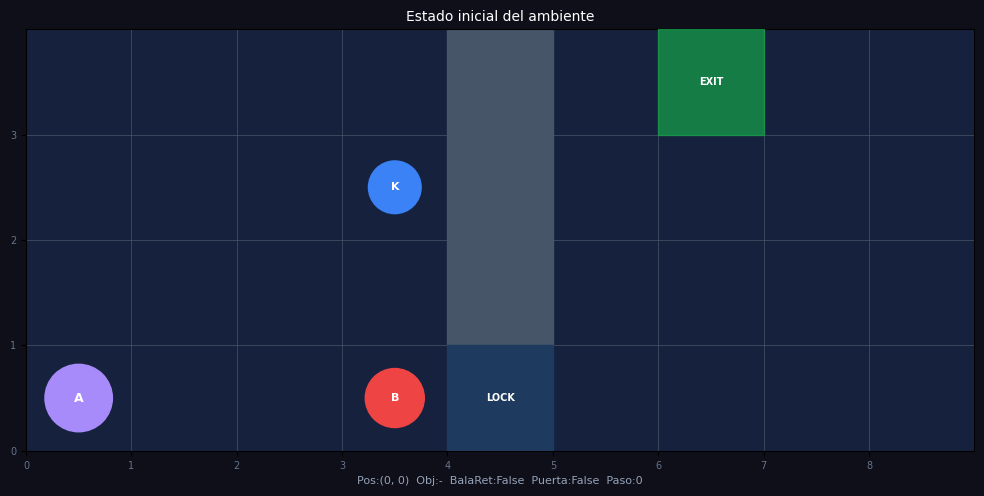

Leyenda: A=Agente (morado) | B=Bola roja | K=Llave azul | EXIT=Salida verde | LOCK=Puerta cerrada

Estado inicial: ((0, 0), False, None, False, False)


In [3]:
# Creación de una instancia del ambiente y renderizado del estado inicial
env_demo = TwoRoomEnv()
fig, ax = env_demo.render(title="Estado inicial del ambiente")
plt.tight_layout()
plt.show()
print("Leyenda: A=Agente (morado) | B=Bola roja | K=Llave azul | EXIT=Salida verde | LOCK=Puerta cerrada")
print(f"\nEstado inicial: {env_demo._get_state()}")

## 3. Agente Q-learning - `QLearningAgent`

### 3.1 Algoritmo Q-learning off-policy

Q-learning aprende asumiendo siempre cuál sería la mejor decisión futura posible, incluso si durante el entrenamiento el agente todavía está explorando.

$$
Q(s,a) \leftarrow (1-\alpha)Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s',a')\right]
$$

### 3.2 Política ε-greedy

* Con probabilidad **ε** se tomará una acción aleatoria (exploración)
* Con probabilidad **1-ε** se tomara la mejor acción conocida (explotación)

### 3.3 Epsilon decay

Cada 100 episodios:

$$
\varepsilon \leftarrow \max(\varepsilon_{\min}, \varepsilon/10)
$$

Esto genera una transición suave de exploración total a explotación casi completa.

### 3.4 Hiperparámetros

| Parámetro | Valor | Justificación |
|---|---|---|
| `epsilon` inicial | 0.9 | Alta exploración al inicio |
| `epsilon` mínimo | 0.01 | 1% de exploración residual |
| `gamma` | 0.9 | Valora recompensas futuras |
| `alpha` | 0.5 | Aprendizaje moderado |
| Episodios | 20,000 | Cobertura suficiente |


In [4]:
# Definición del agente Q-learning
class QLearningAgent:
    def __init__(self, env, epsilon=0.9, gamma=0.9, alpha=0.5):
        self.env     = env
        self.epsilon = epsilon
        self.gamma   = gamma
        self.alpha   = alpha
        self.qtable  = {}

    # Acceso a la Q-tabla
    def get_value(self, state, action) -> float:
        return self.qtable.get((state, action), 0.0)

    def set_value(self, state, action, value):
        self.qtable[(state, action)] = value

    # Selección de acción
    def best_action(self, state) -> str:
        possible = self.env.get_possible_actions()
        q_vals   = [self.get_value(state, a) for a in possible]
        max_q    = max(q_vals)
        best     = [a for a, q in zip(possible, q_vals) if q == max_q]
        return random.choice(best)

    def choose_action(self, state) -> str:
        if random.random() < self.epsilon:
            return random.choice(self.env.get_possible_actions())
        return self.best_action(state)

    # Actualización Q-learning
    def update_values(self, state, action, next_state, reward):
        cq  = self.get_value(state, action)
        mnq = 0.0 if self.env.is_terminal(next_state) else \
              max(self.get_value(next_state, a) for a in ACTIONS)
        self.set_value(state, action,
                       (1 - self.alpha) * cq + self.alpha * (reward + self.gamma * mnq))

    def step(self, action):
        return self.env.step(action)

    # Entrenamiento
    def run(self, episodes=20000, decay_interval=100, epsilon_min=0.01, verbose=True):
        history = {'rewards': [], 'steps': [], 'successes': []}
        for ep in range(episodes):
            state  = self.env.reset()
            total  = 0.0; done = False; success = False
            while not done:
                action = self.choose_action(state)
                ns, r, done, info = self.step(action)
                self.update_values(state, action, ns, r)
                state = ns; total += r
                if 'salida_alcanzada' in info: success = True
            history['rewards'].append(total)
            history['steps'].append(self.env.steps)
            history['successes'].append(int(success))
            # Epsilon decay cada 'decay_interval' episodios
            if (ep + 1) % decay_interval == 0 and self.epsilon > epsilon_min:
                self.epsilon = max(epsilon_min, self.epsilon - self.epsilon / 10)
            if verbose and (ep + 1) % 2000 == 0:
                w  = min(2000, ep + 1)
                rr = history['rewards'][-w:]
                ss = history['successes'][-w:]
                print(f"  Ep {ep+1:>6} | ε={self.epsilon:.4f} | "
                      f"R_avg={sum(rr)/len(rr):>7.3f} | Éxitos={sum(ss)}/{w}")
        return history

    # Evaluación
    def evaluate(self, n=20):
        saved = self.epsilon; self.epsilon = 0.0
        rewards, steps_l, succs = [], [], []
        for _ in range(n):
            state = self.env.reset(); done = False; total = 0.0; suc = False
            while not done:
                action = self.best_action(state)
                state, r, done, info = self.step(action)
                total += r
                if 'salida_alcanzada' in info: suc = True
            rewards.append(total); steps_l.append(self.env.steps); succs.append(int(suc))
        self.epsilon = saved
        return sum(rewards)/n, sum(steps_l)/n, sum(succs)/n

print("Agente QLearningAgent definido.")

Agente QLearningAgent definido.


## 4. Persistencia de la Q-tabla

Se implementan funciones para guardar y cargar la Q-tabla en dos formatos:

- **JSON** — formato legible y recargable; permite continuar entrenamiento o cargar un agente ya entrenado.  
- **CSV** — formato tabular ordenado por Q-valor; ideal para análisis en Excel o pandas.


In [5]:
def save_qtable_json(agent, path="qtable.json"):
    out = {}
    for (state, action), val in agent.qtable.items():
        key = json.dumps([list(state[0]), state[1], state[2], state[3], state[4]])
        out.setdefault(key, {})[action] = round(val, 6)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(out, f, indent=2)
    print(f"Q-tabla guardada → '{path}'  ({len(agent.qtable)} entradas)")

def load_qtable_json(agent, path="qtable.json"):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    agent.qtable = {}
    for key_str, acts in data.items():
        r = json.loads(key_str)
        state = (tuple(r[0]), r[1], r[2], r[3], r[4])
        for action, val in acts.items():
            agent.qtable[(state, action)] = val
    print(f"Q-tabla cargada  ← '{path}'  ({len(agent.qtable)} entradas)")

def save_qtable_csv(agent, path="qtable.csv"):
    with open(path, 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(['pos_col','pos_row','tiene_objeto','tipo_obj',
                    'bola_retirada','puerta_abierta','accion','q_valor'])
        for (state, action), val in sorted(agent.qtable.items(),
                                            key=lambda x: x[1], reverse=True):
            pos, ho, ot, br, da = state
            w.writerow([pos[0], pos[1], ho, ot, br, da, action, f"{val:.6f}"])
    print(f"Q-tabla guardada → '{path}'  ({len(agent.qtable)} entradas)")

print("Funciones de persistencia definidas.")

Funciones de persistencia definidas.


## 5. Entrenamiento del Agente

Se crea el ambiente y el agente con los hiperparámetros óptimos y se ejecutan 20,000 episodios.

Durante el entrenamiento se registran por episodio:
- Recompensa acumulada
- Número de pasos
- Éxito (1 si llegó a la salida, 0 si timeout)

In [6]:
# Crear ambiente y agente
env   = TwoRoomEnv()
agent = QLearningAgent(env, epsilon=0.9, gamma=0.9, alpha=0.5)

# Entrenar
EPISODES = 20000
print(f"Entrenando {EPISODES:,} episodios...")
t0      = time.time()
history = agent.run(EPISODES, decay_interval=100, epsilon_min=0.01, verbose=True)
elapsed = time.time() - t0

print(f"\nTiempo de entrenamiento : {elapsed:.1f}s")
print(f"Entradas en Q-tabla      : {len(agent.qtable)}")
print(f"Epsilon final            : {agent.epsilon:.4f}")

Entrenando 20,000 episodios...
  Ep   2000 | ε=0.1094 | R_avg= -3.498 | Éxitos=911/2000
  Ep   4000 | ε=0.0133 | R_avg=  1.470 | Éxitos=1866/2000
  Ep   6000 | ε=0.0100 | R_avg=  1.754 | Éxitos=1906/2000
  Ep   8000 | ε=0.0100 | R_avg=  1.661 | Éxitos=1880/2000
  Ep  10000 | ε=0.0100 | R_avg=  1.911 | Éxitos=1934/2000
  Ep  12000 | ε=0.0100 | R_avg=  1.257 | Éxitos=1838/2000
  Ep  14000 | ε=0.0100 | R_avg=  1.939 | Éxitos=1953/2000
  Ep  16000 | ε=0.0100 | R_avg=  1.310 | Éxitos=1817/2000
  Ep  18000 | ε=0.0100 | R_avg=  1.494 | Éxitos=1874/2000
  Ep  20000 | ε=0.0100 | R_avg=  1.537 | Éxitos=1859/2000

Tiempo de entrenamiento : 7.0s
Entradas en Q-tabla      : 533
Epsilon final            : 0.0100


In [7]:
# Guardar Q-tabla
save_qtable_json(agent, "qtable.json")
save_qtable_csv(agent,  "qtable.csv")

Q-tabla guardada → 'qtable.json'  (533 entradas)
Q-tabla guardada → 'qtable.csv'  (533 entradas)


## 6. Curvas de Aprendizaje

Las curvas muestran cómo evoluciona el agente a lo largo del entrenamiento.  
Se trazan tres métricas con media móvil para suavizar la variabilidad episódica.

**Tres fases identificables:**
1. Exploración (ep 0-2000, ε = 0.9-0.1): el agente explora aleatoriamente; recompensa negativa.  
2. Transición (ep 2000-4000, ε = 0.1-0.01): combina conocimiento adquirido con algo de exploración; la tasa de éxito sube rápidamente.  
3. Explotación (ep 4000+, ε = 0.01): convergencia a la política óptima; éxito sostenido >90%.


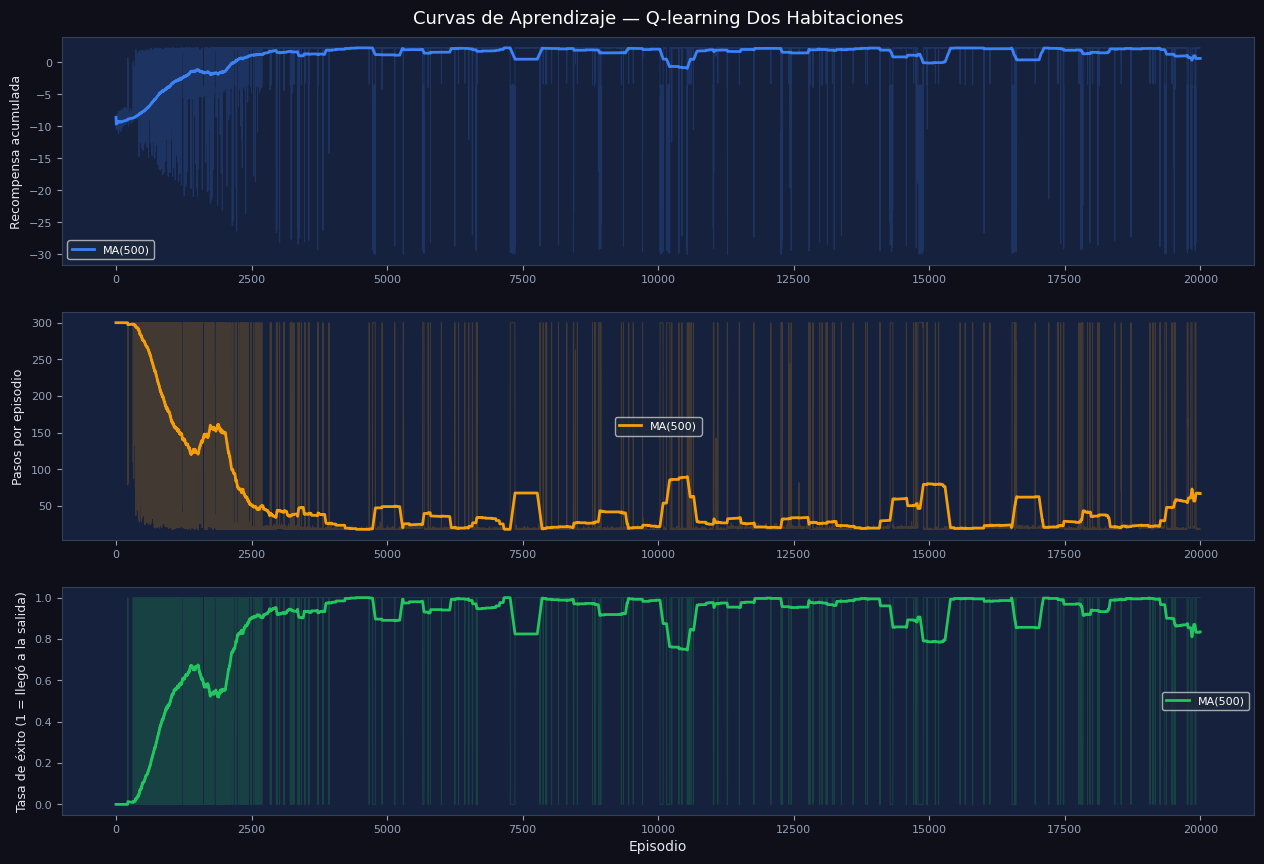

In [8]:
def plot_training_inline(history):
    R = history['rewards']; S = history['steps']; X = history['successes']
    n = len(R); w = max(1, min(500, n // 10))

    def ma(d):
        out = []
        for i in range(len(d)):
            sl = d[max(0, i-w):i+1]
            out.append(sum(sl) / len(sl))
        return out

    fig, axes = plt.subplots(3, 1, figsize=(13, 9))
    fig.patch.set_facecolor('#0f0f1a')
    specs = [(R, '#3b82f6', 'Recompensa acumulada'),
             (S, '#f59e0b', 'Pasos por episodio'),
             (X, '#22c55e', 'Tasa de éxito (1 = llegó a la salida)')]
    for ax, (d, c, yl) in zip(axes, specs):
        ax.set_facecolor('#16213e')
        ax.plot(d,     color=c, alpha=0.2, lw=0.7)
        ax.plot(ma(d), color=c, lw=2.0, label=f'MA({w})')
        ax.set_ylabel(yl, color='#e2e8f0', fontsize=9)
        ax.tick_params(colors='#94a3b8', labelsize=8)
        for sp in ax.spines.values(): sp.set_color('#334155')
        ax.legend(facecolor='#1e293b', labelcolor='white', fontsize=8)
    axes[0].set_title('Curvas de Aprendizaje — Q-learning Dos Habitaciones',
                      color='white', fontsize=13, pad=10)
    axes[2].set_xlabel('Episodio', color='#e2e8f0', fontsize=10)
    plt.tight_layout(pad=2)
    plt.show()

plot_training_inline(history)

La figura presenta las curvas de aprendizaje del algoritmo Q-learning aplicado al ambiente de “dos habitaciones”. Se muestran tres métricas principales a lo largo de 20000 episodios de entrenamiento:
* Recompensa acumulada
* Número de pasos por episodio
* Tasa de éxito
 
En cada gráfico, la línea tenue representa los valores individuales de cada episodio, mientras que la línea gruesa corresponde a una media móvil de 500 episodios, utilizada para visualizar la tendencia general del aprendizaje.

En la primera gráfica se observa la evolución de la recompensa acumulada. Durante los episodios iniciales, el agente obtiene recompensas fuertemente negativas debido a la exploración aleatoria y a la ausencia de una política eficiente. Sin embargo, conforme avanza el entrenamiento, la recompensa promedio aumenta progresivamente hasta estabilizarse en valores cercanos al óptimo. A pesar de esta convergencia, continúan apareciendo caídas abruptas y aisladas, asociadas principalmente a episodios de exploración en los que el agente ejecuta acciones subóptimas.

La segunda gráfica muestra la cantidad de pasos requeridos para completar cada episodio. Inicialmente, el agente alcanza con frecuencia el límite máximo de pasos permitido, lo que indica incapacidad para encontrar la salida de manera eficiente. Posteriormente, el número promedio de pasos disminuye de forma significativa y converge hacia trayectorias mucho más cortas. Esto evidencia que el agente aprende rutas más directas y eficientes hacia el objetivo. Las fluctuaciones esporádicas que persisten en etapas avanzadas del entrenamiento reflejan nuevamente la influencia de la exploración aleatoria.

Finalmente, la tercera gráfica presenta la tasa de éxito del agente, definida como la proporción de episodios en los que logra alcanzar la salida. Se observa un crecimiento progresivo desde valores cercanos a cero hasta una convergencia próxima a uno, indicando que el agente logra resolver exitosamente el entorno en la gran mayoría de los episodios. Las pequeñas disminuciones temporales en la tasa de éxito son coherentes con el comportamiento exploratorio propio de políticas ε-greedy utilizadas en Q-learning.

En conjunto, las tres métricas evidencian una convergencia adecuada del algoritmo. El agente aprende progresivamente una política efectiva, incrementando su recompensa esperada, reduciendo la cantidad de pasos necesarios y maximizando la probabilidad de éxito. Las oscilaciones observadas incluso en etapas tardías del entrenamiento son normales en algoritmos basados en exploración y no necesariamente indican inestabilidad del aprendizaje.

## 7. Evaluación y Casos de Prueba

### 7.1 Evaluación cuantitativa

Se ejecutan 20 episodios con `ε = 0` (solo explotación) para medir el desempeño real del agente entrenado.


In [9]:
# Evaluación cuantitativa
avg_r, avg_s, sr = agent.evaluate(n=20)

print(f"  {'Métrica':<28} {'Valor':>10}")
print(f"  {'Tasa de éxito':<28} {sr*100:>9.1f}%")
print(f"  {'Recompensa promedio':<28} {avg_r:>10.3f}")
print(f"  {'Pasos promedio':<28} {avg_s:>10.1f}")
print(f"  {'Recompensa máx. teórica':<28} {'2.40':>10}")
print(f"  {'Eficiencia vs. óptimo':<28} {avg_r/2.4*100:>9.1f}%")

  Métrica                           Valor
  Tasa de éxito                    100.0%
  Recompensa promedio               2.280
  Pasos promedio                     18.0
  Recompensa máx. teórica            2.40
  Eficiencia vs. óptimo             95.0%


### 7.2 Trayectorias de casos de prueba

Visualizamos **3 episodios completos** de evaluación.  
La línea naranja muestra el camino recorrido (más opaca = paso más reciente).

**Símbolos en el mapa:**
- `B` = recogió bola
- `K` = recogió llave
- `O` = abrió puerta
- `X` = cruzó puerta
- `S` = llegó a la salida


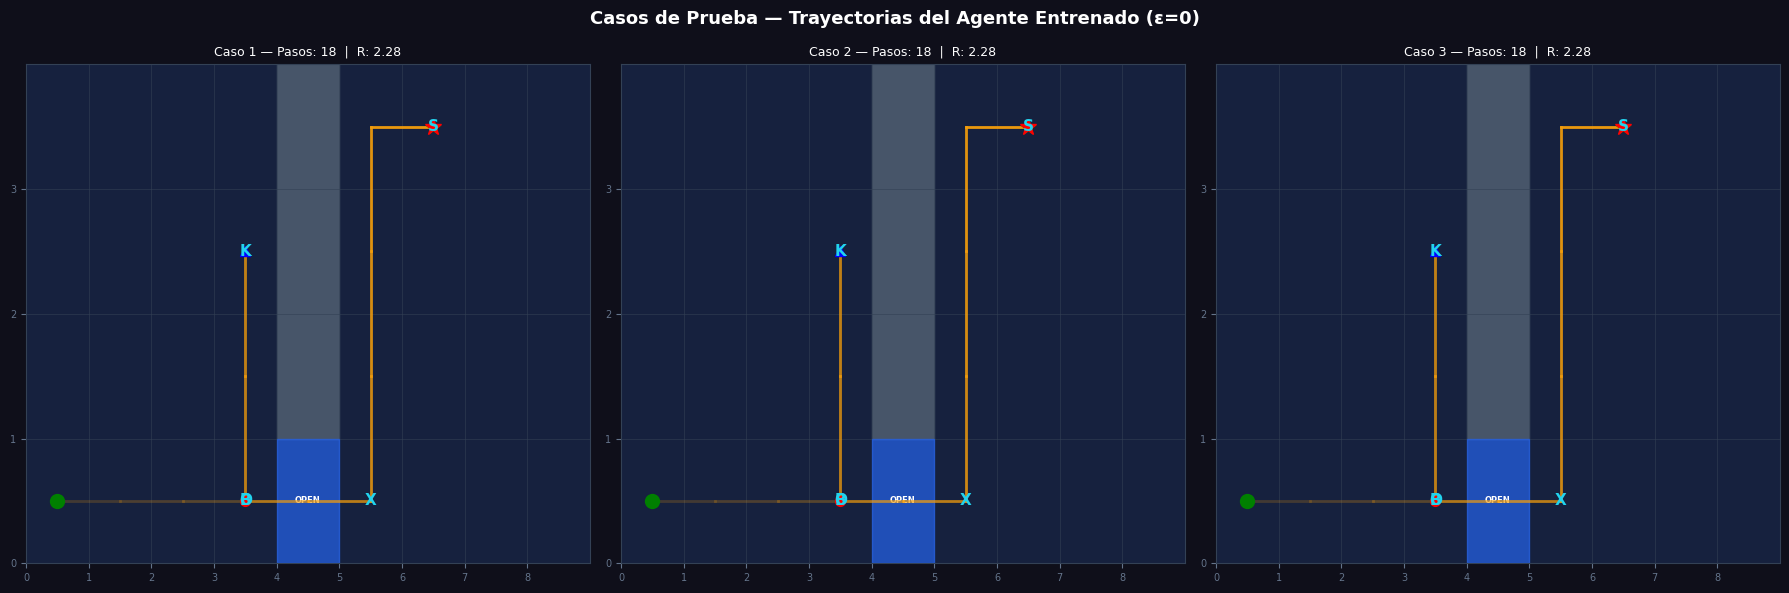

In [10]:
_HITO_SYM = {'recogió_bola':'B', 'recogió_llave':'K',
             'abrió_puerta':'O', 'cruzo_puerta':'X', 'salida_alcanzada':'S'}

def plot_test_cases(agent, n=3):
    saved_eps     = agent.epsilon
    agent.epsilon = 0.0

    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle('Casos de Prueba — Trayectorias del Agente Entrenado (ε=0)',
                 color='white', fontsize=13, fontweight='bold')

    for ep_idx, ax in enumerate(axes):
        env2 = TwoRoomEnv()
        ag2  = QLearningAgent(env2, epsilon=0.0)
        ag2.qtable = agent.qtable

        state   = env2.reset()
        traj    = [env2.agent_pos]
        hitos   = []
        done    = False; total_r = 0.0

        while not done:
            action = ag2.best_action(state)
            state, r, done, info = ag2.step(action)
            traj.append(env2.agent_pos)
            total_r += r
            if info in _HITO_SYM:
                hitos.append((env2.agent_pos, info))

        ax.set_facecolor('#16213e')
        ax.add_patch(plt.Rectangle((0,0), DOOR_COL, NROWS, color='#16213e', zorder=0))
        ax.add_patch(plt.Rectangle((DOOR_COL+1,0), NCOLS-DOOR_COL-1, NROWS, color='#16213e', zorder=0))
        ax.add_patch(plt.Rectangle((DOOR_COL,1), 1, NROWS-1, color='#475569', zorder=1))
        dc, dr = DOOR_POS
        ax.add_patch(plt.Rectangle((dc,dr),1,1, color='#2563eb', alpha=0.7, zorder=2))
        ax.text(dc+0.5, dr+0.5, 'OPEN', ha='center', va='center',
                color='white', fontsize=6, fontweight='bold', zorder=3)
        for x in range(NCOLS+1): ax.axvline(x, color='#334155', lw=0.4, zorder=1)
        for y in range(NROWS+1): ax.axhline(y, color='#334155', lw=0.4, zorder=1)

        xs = [p[0]+0.5 for p in traj]; ys = [p[1]+0.5 for p in traj]
        for i in range(len(xs)-1):
            alpha = 0.2 + 0.8 * (i / max(len(xs)-1, 1))
            ax.plot(xs[i:i+2], ys[i:i+2], color='#f59e0b', lw=2, alpha=alpha, zorder=4)
        ax.plot(xs[0], ys[0], 'go', ms=10, zorder=6)
        ax.plot(xs[-1], ys[-1], 'r*', ms=12, zorder=6)

        for pos, info in hitos:
            ax.text(pos[0]+0.5, pos[1]+0.5, _HITO_SYM[info], ha='center', va='center',
                    fontsize=11, color='#22d3ee', fontweight='bold', zorder=7)

        ax.plot(BALL_POS[0]+0.5, BALL_POS[1]+0.5, 'ro', ms=7, zorder=5)
        ax.plot(KEY_POS[0]+0.5,  KEY_POS[1]+0.5,  'b^', ms=7, zorder=5)
        ax.plot(EXIT_POS[0]+0.5, EXIT_POS[1]+0.5, 'g*', ms=10, zorder=5)

        ax.set_xlim(0, NCOLS); ax.set_ylim(0, NROWS)
        ax.set_xticks(range(NCOLS)); ax.set_yticks(range(NROWS))
        ax.tick_params(colors='#64748b', labelsize=7)
        ax.set_title(f'Caso {ep_idx+1} — Pasos: {env2.steps}  |  R: {total_r:.2f}',
                     color='white', fontsize=9)
        for sp in ax.spines.values(): sp.set_color('#334155')

    agent.epsilon = saved_eps
    plt.tight_layout()
    plt.show()

plot_test_cases(agent, n=3)

Los tres casos de prueba son idénticos en recorrido, pasos (18) y recompensa (2.28), lo cual es el resultado esperado para un agente con ε=0: al no haber exploración, la política es completamente determinista y siempre toma las mismas decisiones desde el mismo estado inicial. Esto valida el hecho de que valida que el agente aprendió una política estable. Sobre los resultados obtenidos en terminos de numero de pasos (Pasos = 18) y recompensa acumulada (R=2.28) están muy cerca del óptimo teórico (R=2.4 con 18 pasos mínimos), con la diferencia explicada únicamente por las penalizaciones de paso (12 x -0.01 = -0.12) ya que hay 6 pasos en los que el agente obtiene recompensa positiva. No se observan movimientos redundantes ni intentos fallidos de acciones inválidas, lo que confirma que la política convergió correctamente.

## 8. Mapas de Calor de la Q-tabla

Para cada una de las **6 fases del episodio** (combinaciones de estado discreto) se muestra el **Q-valor máximo** alcanzable desde cada posición.

- Verde = alto valor (cerca del objetivo)  
- Rojo = bajo valor (lejos o con penalizaciones)  
- `W` = muro permanente
- `L` = puerta cerrada

Nota: El estado completo tiene 5 variables, pero pos_agente varía continuamente. Las otras 4 variables booleanas/categóricas definen en qué fase del episodio está el agente. Esta lista fija 6 combinaciones representativas que corresponden a los momentos clave del juego:

(ball_ret, door_open, obj_type, título)
* (False, False, None, Fase 1: nada ha pasado aún)
* (True,  False, 'bola', Fase 2: recogió la bola, puerta sigue cerrada)
* (True,  False, None, Fase 3: soltó la bola, va por la llave)
* (True,  False, 'llave', Fase 4: tiene la llave, va a abrir la puerta)
* (True,  True,  'llave', Fase 5: puerta abierta, cruza al otro lado)
* (True,  True,  None, Fase 6: dejó la llave, va a la salida)

Se puede observar cómo el gradiente de valores cambia entre fases, guiando al agente hacia la subtarea correcta en cada momento.

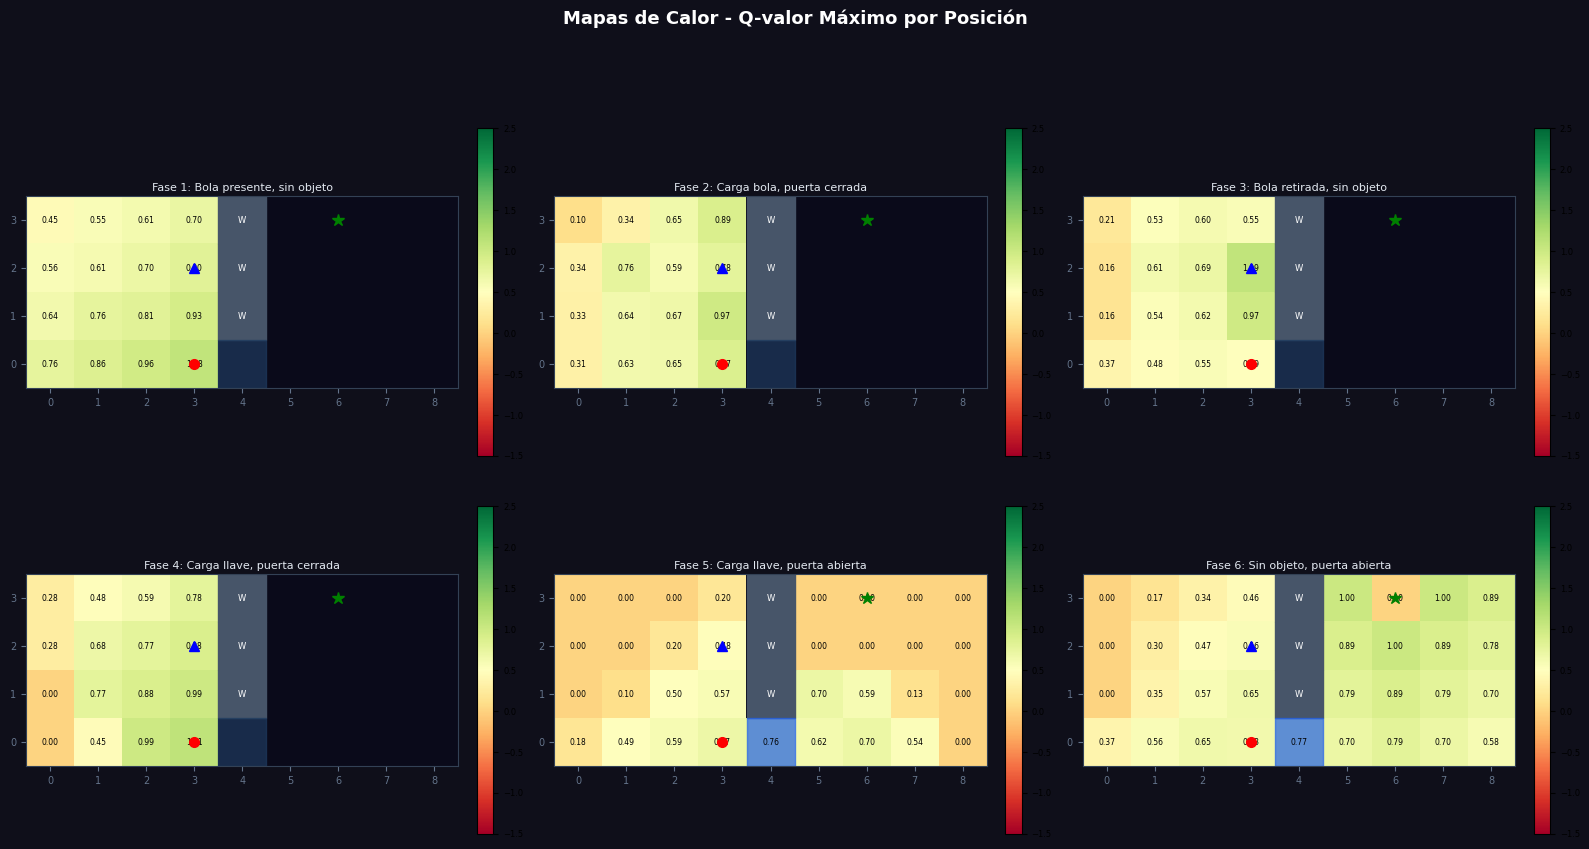

In [11]:
_STATE_COMBOS = [
    (False, False, None,    'Fase 1: Bola presente, sin objeto'),
    (True,  False, 'bola',  'Fase 2: Carga bola, puerta cerrada'),
    (True,  False, None,    'Fase 3: Bola retirada, sin objeto'),
    (True,  False, 'llave', 'Fase 4: Carga llave, puerta cerrada'),
    (True,  True,  'llave', 'Fase 5: Carga llave, puerta abierta'),
    (True,  True,  None,    'Fase 6: Sin objeto, puerta abierta'),
]

def plot_heatmaps(agent):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle('Mapas de Calor - Q-valor Máximo por Posición',
                 color='white', fontsize=13, fontweight='bold', y=0.98)

    for ax, (ball_ret, door_open, obj_type, title) in zip(axes.flat, _STATE_COMBOS):
        grid    = np.full((NROWS, NCOLS), np.nan)
        has_obj = obj_type is not None
        for row in range(NROWS):
            for col in range(NCOLS):
                if col == DOOR_COL and row != DOOR_POS[1]: continue
                if col == DOOR_COL and not door_open:      continue
                if col > DOOR_COL  and not door_open:      continue
                state = ((col, row), has_obj, obj_type, ball_ret, door_open)
                grid[row, col] = max(agent.get_value(state, a) for a in ACTIONS)

        ax.set_facecolor('#0a0a1a')
        im = ax.imshow(grid, cmap='RdYlGn', vmin=-1.5, vmax=2.5,
                       origin='lower', aspect='equal')

        for r in range(NROWS):
            for c in range(NCOLS):
                if c == DOOR_COL and r != DOOR_POS[1]:
                    ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='#475569', zorder=2))
                    ax.text(c, r, 'W', ha='center', va='center', color='white', fontsize=6, zorder=3)
                elif not np.isnan(grid[r, c]):
                    ax.text(c, r, f'{grid[r,c]:.2f}', ha='center', va='center',
                            fontsize=5.5, color='black', zorder=4)

        ax.plot(*BALL_POS, 'ro', ms=7, zorder=5)
        ax.plot(*KEY_POS,  'b^', ms=7, zorder=5)
        ax.plot(*EXIT_POS, 'g*', ms=9, zorder=5)
        dc, dr = DOOR_POS
        ax.add_patch(plt.Rectangle((dc-0.5, dr-0.5), 1, 1,
                     color='#2563eb' if door_open else '#1e3a5f', alpha=0.7, zorder=2))

        ax.set_title(title, color='#e2e8f0', fontsize=8, pad=4)
        ax.set_xlim(-0.5, NCOLS-0.5); ax.set_ylim(-0.5, NROWS-0.5)
        ax.set_xticks(range(NCOLS)); ax.set_yticks(range(NROWS))
        ax.tick_params(colors='#64748b', labelsize=7)
        for sp in ax.spines.values(): sp.set_color('#334155')
        plt.colorbar(im, ax=ax, fraction=0.035, pad=0.04).ax.tick_params(labelsize=6)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_heatmaps(agent)

En los seis paneles se puede ver cómo el agente reorienta su objetivo a lo largo del episodio, reflejando que la Q-tabla capturó correctamente la estructura secuencial del problema.

**Fases 1, 2, 3 y 4, Habitación izquierda (puerta cerrada)**

En las tres fases el gradiente de valores crece de izquierda a derecha, siendo la columna 3 (adyacente a la puerta) la de mayor valor en todos los casos. Sin embargo el *punto de máximo* cambia según el objetivo activo:

- **Fase 1** (bola presente): Los valores mas altos se encuentran cerca de la bola. El agente aprende que lo más valioso es estar cerca de la bola para recogerla cuanto antes.
- **Fase 2** (carga bola): Los valores son más bajos que en la fase anterior. Esto se explica porque cargar la bola es un estado transitorio: el agente necesita soltarla antes de poder recoger la llave, lo que añade pasos adicionales y reduce el valor esperado.
- **Fase 3** (bola retirada, sin objeto): el máximo se desplaza a (3,2) con ~1, exactamente donde está la llave. La Q-tabla "sabe" que el siguiente objetivo es la llave.
- **Fase 4** (carga llave): el máximo baja a (3,0) con ~1, guiando al agente hacia donde ejecutará `open_door`.

**Fases 5 y 6, Habitación derecha (puerta abierta)**

Aquí el patrón cambia radicalmente: los valores más altos aparecen en la habitación derecha, no en la izquierda, y forman un gradiente hacia la salida en (6,3):

- **Fase 5** (carga llave): valores concentrados en la franja central de la habitación derecha. El máximo es 0.76 en (4,0), la celda-puerta, que es el punto de partida del cruce. Los valores decaen hacia los bordes porque alejarse de la ruta óptima acumula penalizaciones de paso.
- **Fase 6** (sin objeto): es el panel con los valores más altos del conjunto, llegando a 1.00 en (5,3), (6,2) y (7, 3), celdas en línea directa con la salida. El gradiente es claro hacia (6,3), lo que indica una política de navegación clara y sin ambigüedades en la habitación derecha.

**Conclusión general**

La progresión de colores entre fases confirma que el agente aprendió una representación coherente del valor de cada posición en función del sub-objetivo activo. No hay valores altos en zonas irrelevantes para cada fase, lo que indica que la Q-tabla no tiene sobreestimaciones y que el entrenamiento convergió correctamente.

## 9. Política Óptima Aprendida

Para cada posición y fase mostramos la **mejor acción** según la Q-tabla.  
El color de fondo indica el tipo de acción:

| Color | Acción |
|---|---|
| Azul | `up` ↑ |
| Amarillo | `down` ↓ |
| Morado | `left` ← |
| Verde | `right` → |
| Rojo | `pick` (P) - recoger |
| Naranja | `drop` (D) - soltar |
| Cian | `open_door` (O) - abrir puerta |


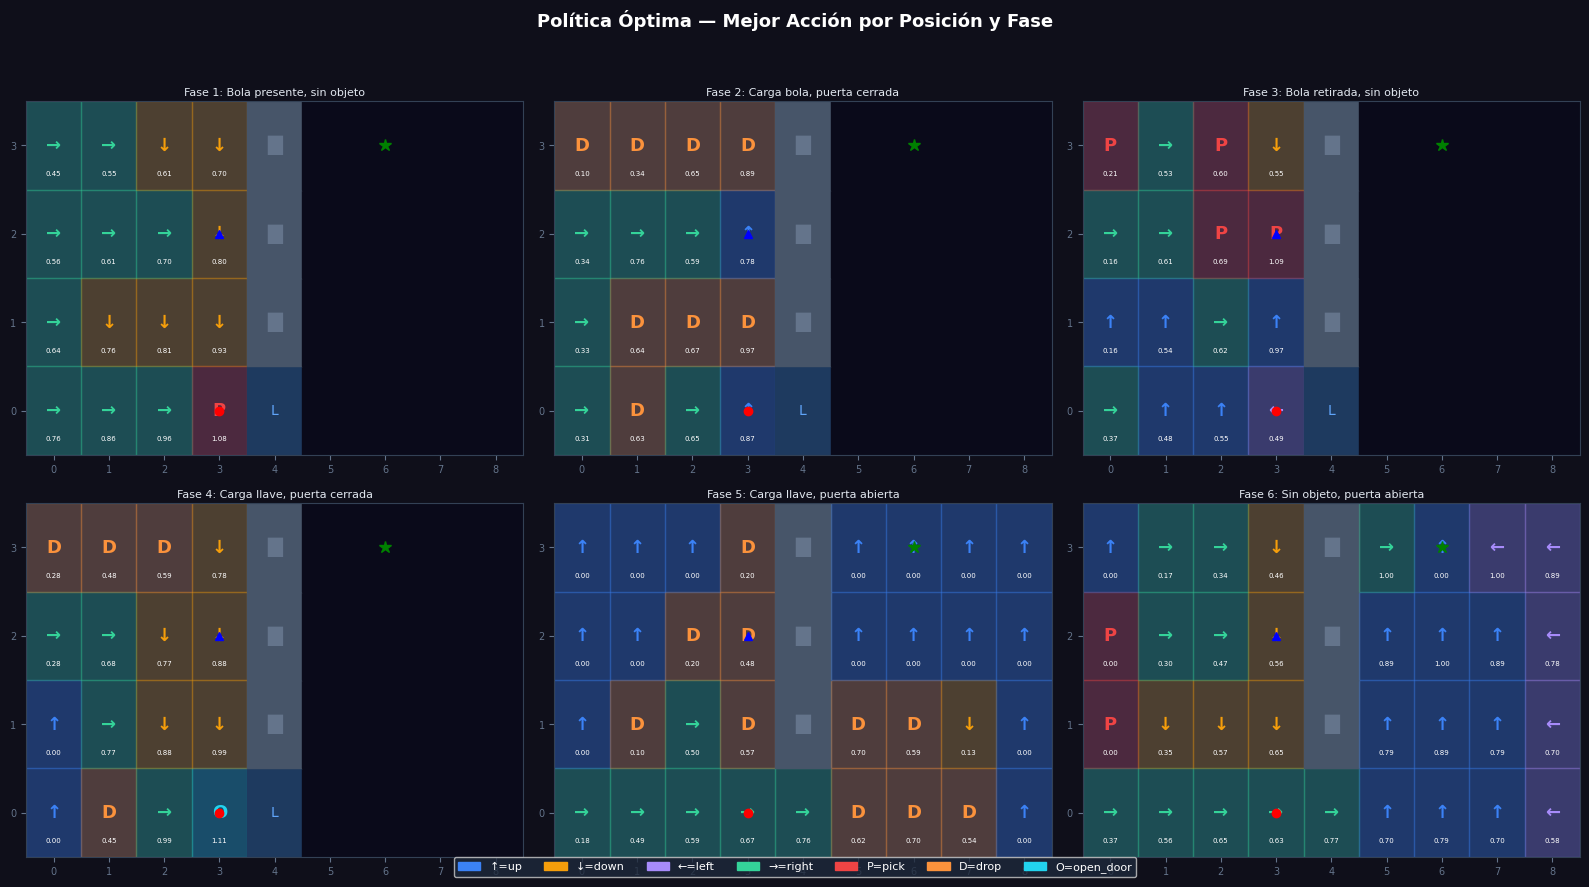

In [12]:
_ACT_ARROWS = {'up':'↑','down':'↓','left':'←','right':'→',
               'pick':'P','drop':'D','open_door':'O'}
_ACT_COLORS = {'up':'#3b82f6','down':'#f59e0b','left':'#a78bfa',
               'right':'#34d399','pick':'#ef4444','drop':'#fb923c',
               'open_door':'#22d3ee'}

def plot_policy_map(agent):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle('Política Óptima — Mejor Acción por Posición y Fase',
                 color='white', fontsize=13, fontweight='bold', y=0.98)

    for ax, (ball_ret, door_open, obj_type, title) in zip(axes.flat, _STATE_COMBOS):
        ax.set_facecolor('#16213e')
        has_obj = obj_type is not None
        for row in range(NROWS):
            for col in range(NCOLS):
                if col == DOOR_COL and row != DOOR_POS[1]:
                    ax.add_patch(plt.Rectangle((col-0.5,row-0.5),1,1,color='#475569',zorder=1))
                    ax.text(col, row, '█', ha='center', va='center', color='#64748b', fontsize=14, zorder=2)
                    continue
                if col == DOOR_COL and not door_open:
                    ax.add_patch(plt.Rectangle((col-0.5,row-0.5),1,1,color='#1e3a5f',zorder=1))
                    ax.text(col, row, 'L', ha='center', va='center', color='#60a5fa', fontsize=10, zorder=2)
                    continue
                if col > DOOR_COL and not door_open:
                    ax.add_patch(plt.Rectangle((col-0.5,row-0.5),1,1,color='#0a0a1a',zorder=1))
                    continue
                state  = ((col, row), has_obj, obj_type, ball_ret, door_open)
                q_vals = [(agent.get_value(state, a), a) for a in ACTIONS]
                bq, best_a = max(q_vals)
                ax.add_patch(plt.Rectangle((col-0.5,row-0.5),1,1,
                    color=_ACT_COLORS[best_a], alpha=0.25, zorder=1))
                ax.text(col, row, _ACT_ARROWS[best_a], ha='center', va='center',
                        fontsize=13, color=_ACT_COLORS[best_a], fontweight='bold', zorder=3)
                ax.text(col, row-0.32, f'{bq:.2f}', ha='center', va='center',
                        fontsize=5, color='white', zorder=3)
        ax.plot(*BALL_POS,'ro',ms=6,zorder=5); ax.plot(*KEY_POS,'b^',ms=6,zorder=5)
        ax.plot(*EXIT_POS,'g*',ms=9,zorder=5)
        ax.set_xlim(-0.5,NCOLS-0.5); ax.set_ylim(-0.5,NROWS-0.5)
        ax.set_xticks(range(NCOLS)); ax.set_yticks(range(NROWS))
        ax.tick_params(colors='#64748b', labelsize=7)
        ax.set_title(title, color='#e2e8f0', fontsize=8, pad=4)
        for sp in ax.spines.values(): sp.set_color('#334155')

    patches = [mpatches.Patch(color=c, label=f'{_ACT_ARROWS[a]}={a}')
               for a, c in _ACT_COLORS.items()]
    fig.legend(handles=patches, loc='lower center', ncol=7,
               facecolor='#1e293b', labelcolor='white', fontsize=8,
               bbox_to_anchor=(0.5, 0.01))
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_policy_map(agent)

Los seis paneles muestran que el agente aprendió una política coherente y orientada a objetivos. En cada fase las acciones no son aleatorias sino que forman patrones direccionales claros que convergen hacia el subobjetivo activo (primero la bola, luego la llave, luego la puerta y por ultimo la salida).

### 9.1 Top 20 pares (Estado, Acción) por Q-valor

Los pares con mayor Q-valor corresponden exactamente a las acciones críticas del problema:  
`pick` en bola/llave, `open_door` desde `(3,0)`, y movimientos directos hacia la salida.


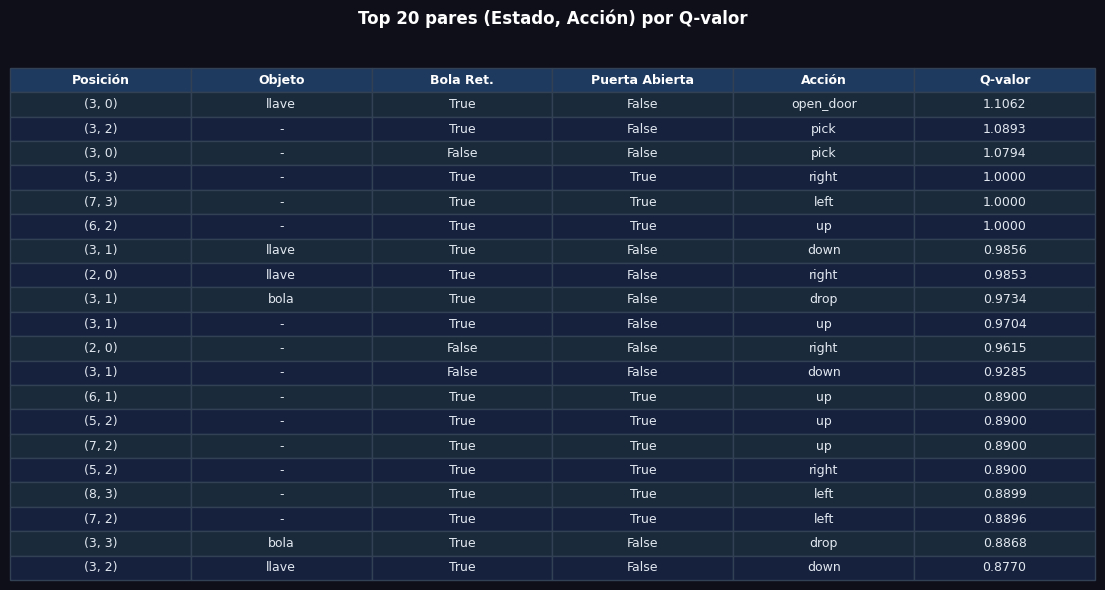

In [13]:
def plot_qtable_summary(agent, top_n=20):
    top  = sorted(agent.qtable.items(), key=lambda x: x[1], reverse=True)[:top_n]
    rows = []
    for (state, action), val in top:
        pos, ho, ot, br, da = state
        rows.append([str(pos), str(ot or '-'), str(br), str(da), action, f'{val:.4f}'])

    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor('#0f0f1a'); ax.set_facecolor('#0f0f1a'); ax.axis('off')
    ax.set_title(f'Top {top_n} pares (Estado, Acción) por Q-valor',
                 color='white', fontsize=12, fontweight='bold', pad=12)

    cols = ['Posición', 'Objeto', 'Bola Ret.', 'Puerta Abierta', 'Acción', 'Q-valor']
    tbl  = ax.table(cellText=rows, colLabels=cols, cellLoc='center',
                    loc='center', bbox=[0.0, 0.0, 1.0, 0.95])
    tbl.auto_set_font_size(False); tbl.set_fontsize(9)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor('#1e3a5f'); cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('#16213e' if r % 2 == 0 else '#1a2a3a')
            cell.set_text_props(color='#e2e8f0')
        cell.set_edgecolor('#334155')
    plt.show()

plot_qtable_summary(agent)

La tabla confirma que los pares con mayor Q-valor corresponden exactamente a las acciones críticas del problema, en el orden esperado:

* El valor más alto pertenece a `open_door` desde (3,0) con la llave en mano, el hito de mayor dependencia del episodio. Le siguen los `pick` sobre la bola y la llave, y los movimientos dentro de la habitación derecha hacia la salida (~0.99–1.00).
* En conjunto, la distribución de valores refleja fielmente la estructura de recompensas diseñada: las acciones más valiosas son exactamente aquellas que desbloquean el siguiente sub-objetivo, validando que el entrenamiento convergió hacia la política correcta.

## 10. Demostración Animada del Agente

Grabamos un episodio completo con el agente entrenado (`ε=0`) y lo mostramos como GIF animado.  
Cada frame muestra la posición del agente, el estado actual y la acción ejecutada.


GIF guardado → 'demo_agent.gif'  (19 frames, 18 pasos)


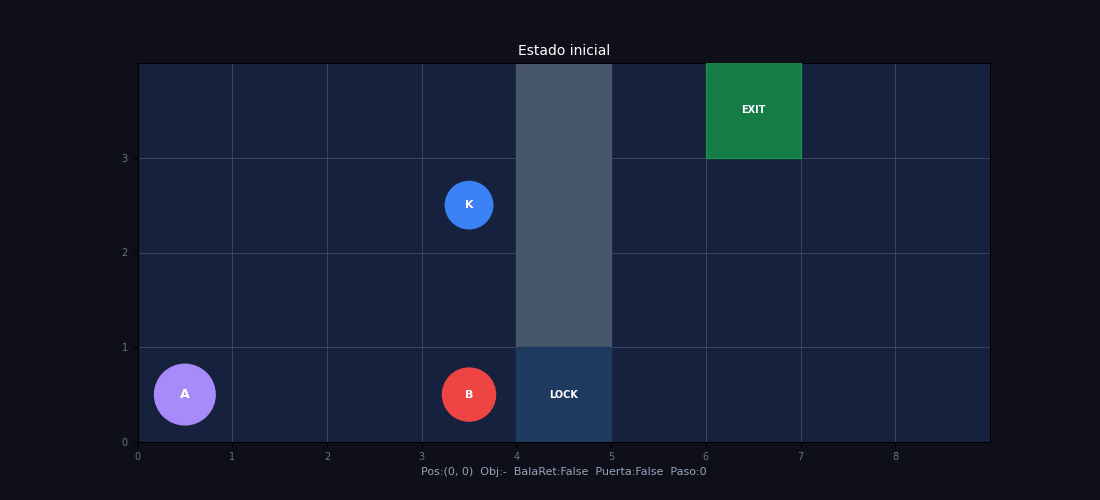

In [14]:
def record_and_show_gif(agent, path="demo_agent.gif", max_steps=150):
    """Graba un episodio completo como GIF y lo muestra en el notebook."""
    saved_eps     = agent.epsilon
    agent.epsilon = 0.0
    state = agent.env.reset(); frames = []; done = False

    def capture(title=""):
        fig, _ = agent.env.render(title=title)
        fig.canvas.draw()
        buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        ww, hh = fig.canvas.get_width_height()
        frames.append(buf.reshape(hh, ww, 4)[:, :, :3].copy())
        plt.close(fig)

    capture("Estado inicial")
    while not done and agent.env.steps < max_steps:
        action = agent.best_action(state)
        state, reward, done, info = agent.step(action)
        capture(f"Acción:{action}  r={reward:.2f}  "
                f"Puerta:{'OPEN' if agent.env.door_open else 'CLOSED'}  Paso:{agent.env.steps}")

    agent.epsilon = saved_eps

    # Guardar GIF
    fig_g = plt.figure(figsize=(11, 5))
    ax_g  = fig_g.add_axes([0, 0, 1, 1]); ax_g.axis('off')
    im    = ax_g.imshow(frames[0])
    def upd(i): im.set_data(frames[i]); return [im]
    ani = animation.FuncAnimation(fig_g, upd, frames=len(frames), interval=400, blit=True)
    ani.save(path, writer='pillow', fps=3)
    plt.close(fig_g)
    print(f"GIF guardado → '{path}'  ({len(frames)} frames, {agent.env.steps} pasos)")
    return path

gif_path = record_and_show_gif(agent, "demo_agent.gif")
display(Image(filename=gif_path))

## 11. Resumen de Resultados

### Desempeño del agente entrenado


In [15]:
# Evaluación final
avg_r, avg_s, sr = agent.evaluate(n=20)


print("RESUMEN FINAL — Agente Q-learning")
print(f"Episodios de entrenamiento : {EPISODES:>20}")
print(f"Entradas en Q-tabla        : {len(agent.qtable):>20,}")
print(f"Epsilon final              : {agent.epsilon:>20.4f}")
print(f"Tasa de éxito (20 ep.)     : {sr*100:>19.1f}%")
print(f"Recompensa promedio        : {avg_r:>20.3f}")
print(f"Pasos promedio             : {avg_s:>20.1f}")
print(f"Recompensa máx. teórica    : {2.40:>20.2f}")
print(f"Eficiencia vs. óptimo      : {avg_r/2.4*100:>19.1f}%")

RESUMEN FINAL — Agente Q-learning
Episodios de entrenamiento :                20000
Entradas en Q-tabla        :                  533
Epsilon final              :               0.0100
Tasa de éxito (20 ep.)     :               100.0%
Recompensa promedio        :                2.280
Pasos promedio             :                 18.0
Recompensa máx. teórica    :                 2.40
Eficiencia vs. óptimo      :                95.0%


El agente tiene una tasa de exito de 100% y como ya se ha mencionado en otros apartados de este reporte su recompensa promedio es 2.28 que corresponde a la recompensa máxima posible menos las penalizaciones de paso (12 x -0.01).

Se encuentra con esto que el agente logra descubrir el orden correcto de las subtareas sin que este fuera impuesto explícitamente. La función de recompensa solo define qué acciones valen más, pero es el agente quien aprende que recoger la bola antes que la llave, y abrir la puerta antes de cruzar, es la secuencia que maximiza la recompensa acumulada.

### Archivos generados

| Archivo | Descripción |
|---|---|
| `qtable.json` | Q-tabla completa en formato JSON (recargable) |
| `qtable.csv` | Q-tabla en CSV ordenada por Q-valor |
| `demo_agent.gif` | Demostración animada del agente entrenado |

---

### Conclusiones

1. Q-learning converge correctamente: en este problema de tareas encadenadas, alcanzando 100% de tasa de éxito con solo 20,000 episodios.
2. La función de recompensa escalonada: es un factor importante, sin las recompensas intermedias (+0.3, +0.5), el agente no descubriría la secuencia correcta durante la exploración.
3. El diseño del estado: (5 variables incluyendo `bola_retirada` y `puerta_abierta`) es fundamental para que el agente pueda distinguir las 6 fases del problema.
4. La eficiencia del 95% respecto al óptimo teórico confirma que el camino aprendido es casi perfecto, con solo los pasos de navegación estrictamente necesarios.


## 12. Pruebas adicionales cargando Q-tabla desde archivo .json
En esta prueba se define un ambiente y un agente de prueba. El agente tiene épsilon con valor 0, y la qtabla se carga desde un archivo .json. Luego se evalua el agente durante 20 episodios.

In [16]:
env_test   = TwoRoomEnv()
agent_test = QLearningAgent(env_test, epsilon=0.0)
load_qtable_json(agent_test, "qtable.json")

Q-tabla cargada  ← 'qtable.json'  (533 entradas)


In [17]:
# Evaluación cuantitativa
avg_r, avg_s, sr = agent_test.evaluate(n=20)
print(f"Tasa de éxito  : {sr*100:.1f}%")
print(f"Recompensa avg : {avg_r:.3f}")
print(f"Pasos avg      : {avg_s:.1f}")

Tasa de éxito  : 100.0%
Recompensa avg : 2.280
Pasos avg      : 18.0


In [18]:
state = env_test.reset()
done  = False

while not done:
    action = agent_test.best_action(state)
    state, reward, done, info = agent_test.step(action)
    print(f"  Pos: {env_test.agent_pos}  Acción: {action:10}  r={reward:+.2f}  {info}")

  Pos: (1, 0)  Acción: right       r=-0.01  
  Pos: (2, 0)  Acción: right       r=-0.01  
  Pos: (3, 0)  Acción: right       r=-0.01  
  Pos: (3, 0)  Acción: pick        r=+0.30  recogió_bola
  Pos: (3, 1)  Acción: up          r=-0.01  
  Pos: (3, 1)  Acción: drop        r=+0.10  soltó_bola
  Pos: (3, 2)  Acción: up          r=-0.01  
  Pos: (3, 2)  Acción: pick        r=+0.30  recogió_llave
  Pos: (3, 1)  Acción: down        r=-0.01  
  Pos: (3, 0)  Acción: down        r=-0.01  
  Pos: (3, 0)  Acción: open_door   r=+0.50  abrió_puerta
  Pos: (4, 0)  Acción: right       r=-0.01  
  Pos: (5, 0)  Acción: right       r=+0.20  cruzo_puerta
  Pos: (5, 1)  Acción: up          r=-0.01  
  Pos: (5, 1)  Acción: drop        r=-0.01  soltó_llave
  Pos: (6, 1)  Acción: right       r=-0.01  
  Pos: (6, 2)  Acción: up          r=-0.01  
  Pos: (6, 3)  Acción: up          r=+1.00  salida_alcanzada


Se confirma funcionamiento adecuado de la funcion para cargar q-tabla desde archivo json y se confirma operación adecuada del agente con dicha tabla.